In [1]:
!pip install pybiomart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pybiomart import Dataset

# Load the finalized test suite from Step 1
try:
    df_snps = pd.read_csv("Step1_Significant_SNPs.csv")
    snp_list = df_snps['rsid'].unique().tolist()
    print(" Step 1 Checkpoint Loaded Successfully.")
    print(f"   ↳ Input baseline: {len(snp_list)} unique RefSNP IDs ready for coordinate mapping.")
except FileNotFoundError:
    print(" Error: 'Step1_Significant_SNPs.csv' not found. Ensure Step 1 completed successfully.")

Defaulting to user installation because normal site-packages is not writeable
 Step 1 Checkpoint Loaded Successfully.
   ↳ Input baseline: 2783 unique RefSNP IDs ready for coordinate mapping.


In [2]:
# Define batch size constraints to optimize server payload limits
BATCH_SIZE = 500
all_mapping_results = []

print(" Connecting to Ensembl BioMart (Human Variation Server)...")
try:
    # Target the human variation dataset (GRCh38.p14 reference assembly)
    var_dataset = Dataset(name='hsapiens_snp', host='http://www.ensembl.org')
    
    print(f" Querying {len(snp_list)} SNPs in batches of {BATCH_SIZE}...")
    for i in range(0, len(snp_list), BATCH_SIZE):
        batch = snp_list[i:i + BATCH_SIZE]
        print(f"    Dispatched Batch {i//BATCH_SIZE + 1} ({i} to {min(i + BATCH_SIZE, len(snp_list))})...")
        
        results = var_dataset.query(
            attributes=['refsnp_id', 'ensembl_gene_stable_id', 'associated_gene', 'consequence_type_tv'], 
            filters={'snp_filter': batch}
        )
        all_mapping_results.append(results)
        time.sleep(1)  # Enforce programmatic politeness to prevent API lockout

    # Consolidate intermediate batch tables
    df_initial_map = pd.concat(all_mapping_results, ignore_index=True)
    df_initial_map.columns = ['rsid', 'Gene_ID', 'Gene_Name', 'Consequence']
    
    # Save raw mapping snapshot for audit trails
    df_initial_map.to_csv('mapped_snps_initial.csv', index=False)
    print("\n" + "="*45)
    print(" PRIMARY GENOMIC MAPPING COMPLETION")
    print(f"Total functional transcript records recovered: {len(df_initial_map)}")
    print("="*45)
    print(df_initial_map['Consequence'].value_counts().head(5))

except Exception as e:
    print(f" Critical API Exception during mapping: {e}")

 Connecting to Ensembl BioMart (Human Variation Server)...
 Querying 2783 SNPs in batches of 500...
    Dispatched Batch 1 (0 to 500)...
    Dispatched Batch 2 (500 to 1000)...
    Dispatched Batch 3 (1000 to 1500)...
    Dispatched Batch 4 (1500 to 2000)...
    Dispatched Batch 5 (2000 to 2500)...
    Dispatched Batch 6 (2500 to 2783)...

 PRIMARY GENOMIC MAPPING COMPLETION
Total functional transcript records recovered: 3676
Consequence
intron_variant         1590
missense_variant        158
3_prime_UTR_variant      68
synonymous_variant       50
5_prime_UTR_variant      12
Name: count, dtype: int64


In [3]:
# Cleanse data and extract unique Ensembl Gene IDs to form the next query layer
df_clean_map = pd.read_csv('mapped_snps_initial.csv').dropna(subset=['Gene_ID'])
gene_list = df_clean_map['Gene_ID'].unique().tolist()

# Downscale batch size to handle heavier positional coordinate data strings safely
GENE_BATCH_SIZE = 200
all_utr_results = []

print(" Connecting to Ensembl BioMart (Human Core Structural Server)...")
try:
    gene_dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')
    print(f" Fetching structural 3' UTR coordinates for {len(gene_list)} unique host genes...")
    
    for i in range(0, len(gene_list), GENE_BATCH_SIZE):
        batch = gene_list[i:i + GENE_BATCH_SIZE]
        print(f"   ↳ Processing Structural Batch {i//GENE_BATCH_SIZE + 1}...")
        
        results = gene_dataset.query(
            attributes=['ensembl_gene_id', '3_utr_start', '3_utr_end'], 
            filters={'link_ensembl_gene_id': batch}
        )
        all_utr_results.append(results)
        time.sleep(1)

    if all_utr_results:
        utr_coords = pd.concat(all_utr_results, ignore_index=True)
        # Handle column naming variation dynamically based on server return values
        col_name = 'Gene stable ID' if 'Gene stable ID' in utr_coords.columns else 'Ensembl Gene ID'
        
        # Merge structural coordinates back onto our variation records
        merged_df = pd.merge(df_clean_map, utr_coords, left_on='Gene_ID', right_on=col_name)
        
        # AUTOMATED FILTER: Retain ONLY mutations with confirmed 3' UTR molecular location
        final_utr_df = merged_df[merged_df['Consequence'].str.contains('3_prime_UTR_variant', case=False, na=False)].copy()
        
        final_utr_df.to_csv('filtered_3UTR_snps.csv', index=False)
        print("\n" + "="*45)
        print(" REGION FILTRATION COMPLETION")
        print(f"Total records mapped explicitly to the 3' UTR interface: {len(final_utr_df)}")
        print("="*45)
    else:
        print(" Critical Exception: No coordinate values returned from Core Server.")
except Exception as e:
    print(f" Processing Error in Core alignment sub-routine: {e}")

 Connecting to Ensembl BioMart (Human Core Structural Server)...
 Fetching structural 3' UTR coordinates for 836 unique host genes...
   ↳ Processing Structural Batch 1...
   ↳ Processing Structural Batch 2...
   ↳ Processing Structural Batch 3...
   ↳ Processing Structural Batch 4...
   ↳ Processing Structural Batch 5...

 REGION FILTRATION COMPLETION
Total records mapped explicitly to the 3' UTR interface: 882


In [4]:
# Load structural subset and correct position data strings to native numeric objects
df_calc = pd.read_csv('filtered_3UTR_snps.csv')
start_col = "3' UTR start" if "3' UTR start" in df_calc.columns else "3_utr_start"
end_col = "3' UTR end" if "3' UTR end" in df_calc.columns else "3_utr_end"

# Mathematical transformation: Quantifying overall transcript lengths
df_calc['utr_length'] = df_calc[end_col] - df_calc[start_col]

# Isoform Resolution Filter: Sort descending and retain ONLY the longest representative model per mutation
df_max_isoform = df_calc.sort_values(by=['rsid', 'utr_length'], ascending=[True, False])
df_unique_utr = df_max_isoform.drop_duplicates(subset=['rsid'], keep='first')

print(f" Overlapping transcripts compressed. {len(df_unique_utr)} unique variants isolated.")
print(" Connecting to Ensembl Variation for target allele string retrieval...")

try:
    snp_dataset = Dataset(name='hsapiens_snp', host='http://www.ensembl.org')
    rsid_list = df_unique_utr['rsid'].tolist()
    
    # Query for the physical reference/alternative allele strings
    allele_info = snp_dataset.query(attributes=['refsnp_id', 'allele'], filters={'snp_filter': rsid_list})
    
    # Standardize column naming rules to execute clean pandas dataframe merge
    allele_info.columns = ['rsid', 'Allele_Sequence']
    
    # Final step compilation merge
    ready_for_prediction = pd.merge(df_unique_utr, allele_info, on='rsid')
    ready_for_prediction.to_csv('ready_for_prediction.csv', index=False)
    
    print("\n" + "="*45)
    print(" STEP 2 COMPLETION: PIPELINE READY FOR PREDICTION")
    print(f"Total high-confidence physical variants fully mapped: {len(ready_for_prediction)}")
    print(f"Total unique verified rsIDs inside final payload: {ready_for_prediction['rsid'].nunique()}")
    print("="*45)
    print("\n Final dataset structural preview:")
    print(ready_for_prediction[['rsid', 'Gene_Name', 'utr_length', 'Allele_Sequence']].head(10))

except Exception as e:
    print(f" Execution failure during final allele retrieval: {e}")

 Overlapping transcripts compressed. 40 unique variants isolated.
 Connecting to Ensembl Variation for target allele string retrieval...

 STEP 2 COMPLETION: PIPELINE READY FOR PREDICTION
Total high-confidence physical variants fully mapped: 42
Total unique verified rsIDs inside final payload: 40

 Final dataset structural preview:
          rsid      Gene_Name  utr_length Allele_Sequence
0      rs10119            NaN      2331.0             G/A
1   rs10422253           OPA3      7232.0           A/G/T
2    rs1048699  EIF5AP3,NKPD1       811.0             C/T
3    rs1065712            NaN      2698.0             G/C
4    rs1065712            NaN      2698.0             C/G
5      rs10903            NaN      4345.0           G/A/T
6      rs11343           COQ7      1255.0           T/C/G
7  rs114812713          TREM2      2562.0           G/A/C
8   rs11557080          RAB29      2355.0             G/A
9      rs13664            NaN      3203.0           G/C/T


 Figure successfully saved as 'Thesis_Step2_UTR_Length_Architecture.png'


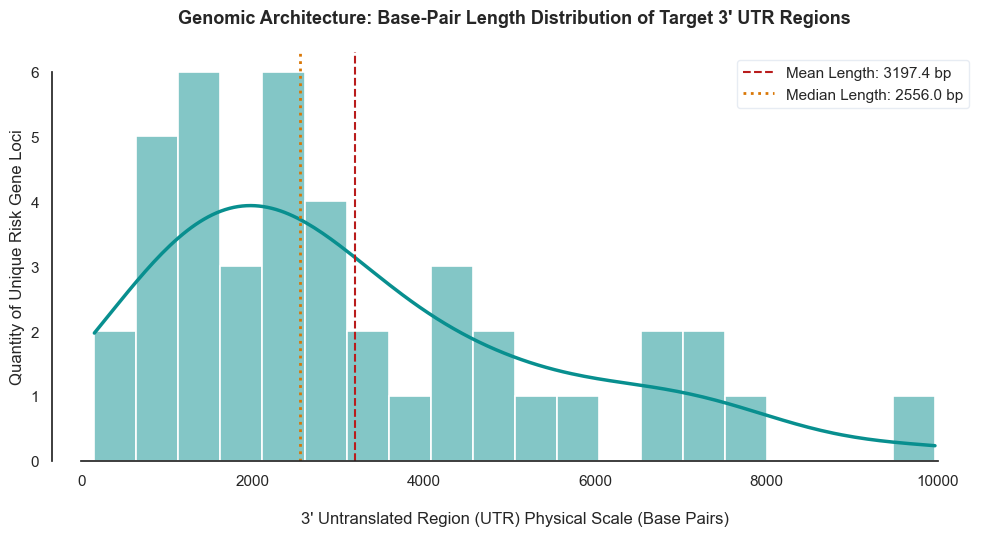

In [5]:
# Initialize publication-grade aesthetic parameters
sns.set_theme(style="white")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot structural kernel density distribution alongside clean histogram bars
sns.histplot(
    data=ready_for_prediction, 
    x='utr_length', 
    bins=20, 
    kde=True, 
    color='#088F8F', 
    edgecolor='white',
    linewidth=1.2,
    line_kws={'linewidth': 2.5, 'color': '#0d9488'},
    ax=ax
)

# Highlight data density parameters using mean/median annotation metrics
mean_val = ready_for_prediction['utr_length'].mean()
median_val = ready_for_prediction['utr_length'].median()

ax.axvline(mean_val, color='#b91c1c', linestyle='--', linewidth=1.5, label=f'Mean Length: {mean_val:.1f} bp')
ax.axvline(median_val, color='#d97706', linestyle=':', linewidth=2, label=f'Median Length: {median_val:.1f} bp')

# Annotate structural plot properties
ax.set_title("Genomic Architecture: Base-Pair Length Distribution of Target 3' UTR Regions\n", weight='bold', fontsize=13)
ax.set_xlabel("\n3' Untranslated Region (UTR) Physical Scale (Base Pairs)", fontsize=12)
ax.set_ylabel("Quantity of Unique Risk Gene Loci", fontsize=12)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

sns.despine(trim=True)
plt.tight_layout()

# Save figure file instantly at high-resolution 300 DPI
plt.savefig("Thesis_Step2_UTR_Length_Architecture.png", dpi=300, bbox_inches='tight')
print(" Figure successfully saved as 'Thesis_Step2_UTR_Length_Architecture.png'")
plt.show()